<a href="https://colab.research.google.com/github/aditi-tawade-ai/Banknotes-Authentication/blob/main/Banknotes-Authentication/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# import the libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split


In [6]:
# read the dataset
path = '/content/banknotes (1).csv'
bn = pd.read_csv(path)
bn.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [16]:
# length of columns
len(bn)

1372

In [32]:
bn.shape

(1372, 5)

In [7]:
bn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [8]:
# checking if these are missing values
bn.isna().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [11]:
# checking if any outliers
bn.describe().T

,count,mean,std,min,25%,50%,75%,max
Variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
Skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
Curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
Entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
Class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


In [9]:
# drop the target column
x = bn.drop('Class',axis=1)
x[:2]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210


In [62]:
x[-2:]

,Variance,Skewness,Curtosis,Entropy
1370,-3.5637,-8.38270,12.3930,-1.2823
1371,-2.5419,-0.65804,2.6842,1.1952


In [17]:
y = bn.Class
y[-5:]

,Class
1367,1
1368,1
1369,1
1370,1
1371,1


In [33]:
# split the data for training
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

# Decision tree using Gini

In [45]:
# create decision tree using Gini and train the model
dt_gini = DecisionTreeClassifier(criterion='gini',random_state=40)
dt_gini.fit(X_train,y_train)

DecisionTreeClassifier(random_state=40)

In [46]:
# test the testing data
y_pred = dt_gini.predict(X_test)
y_pred

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1])

In [47]:
accuracy_gini = accuracy_score(y_test,y_pred)*100
print('Accuracy for Gini is:',accuracy_gini)

Accuracy for Gini is: 98.9090909090909


In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       145
           1       0.98      0.99      0.99       130

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [52]:
from sklearn.metrics import confusion_matrix
cm_gini = confusion_matrix(y_test,y_pred)
cm_gini

array([[143,   2],
       [  1, 129]])

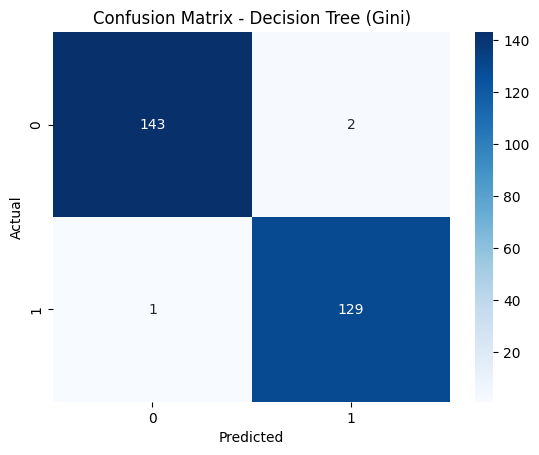

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_gini, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Gini)")
plt.show()

# Decision Tree using Entropy

In [42]:
# import dt using entropy and train the model
dt_en = DecisionTreeClassifier(criterion='entropy')
dt_en.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [43]:
# predict the testing data
y_pred_en = dt_en.predict(X_test)
y_pred_en

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1])

In [44]:
acc_en = accuracy_score(y_test,y_pred_en)*100
print('Accuracy for entropy is:',acc_en)

Accuracy for entropy is: 97.45454545454545


In [49]:
print(classification_report(y_test,y_pred_en))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       145
           1       0.98      0.97      0.97       130

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275



In [54]:
cm_en = confusion_matrix(y_test,y_pred_en)
cm_en

array([[142,   3],
       [  4, 126]])

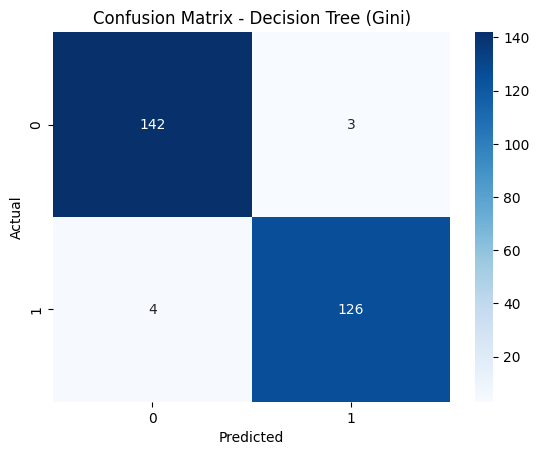

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_en, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Gini)")
plt.show()

- From above observations we can see that accuracy for Gini is greater so we will choose gini for our model

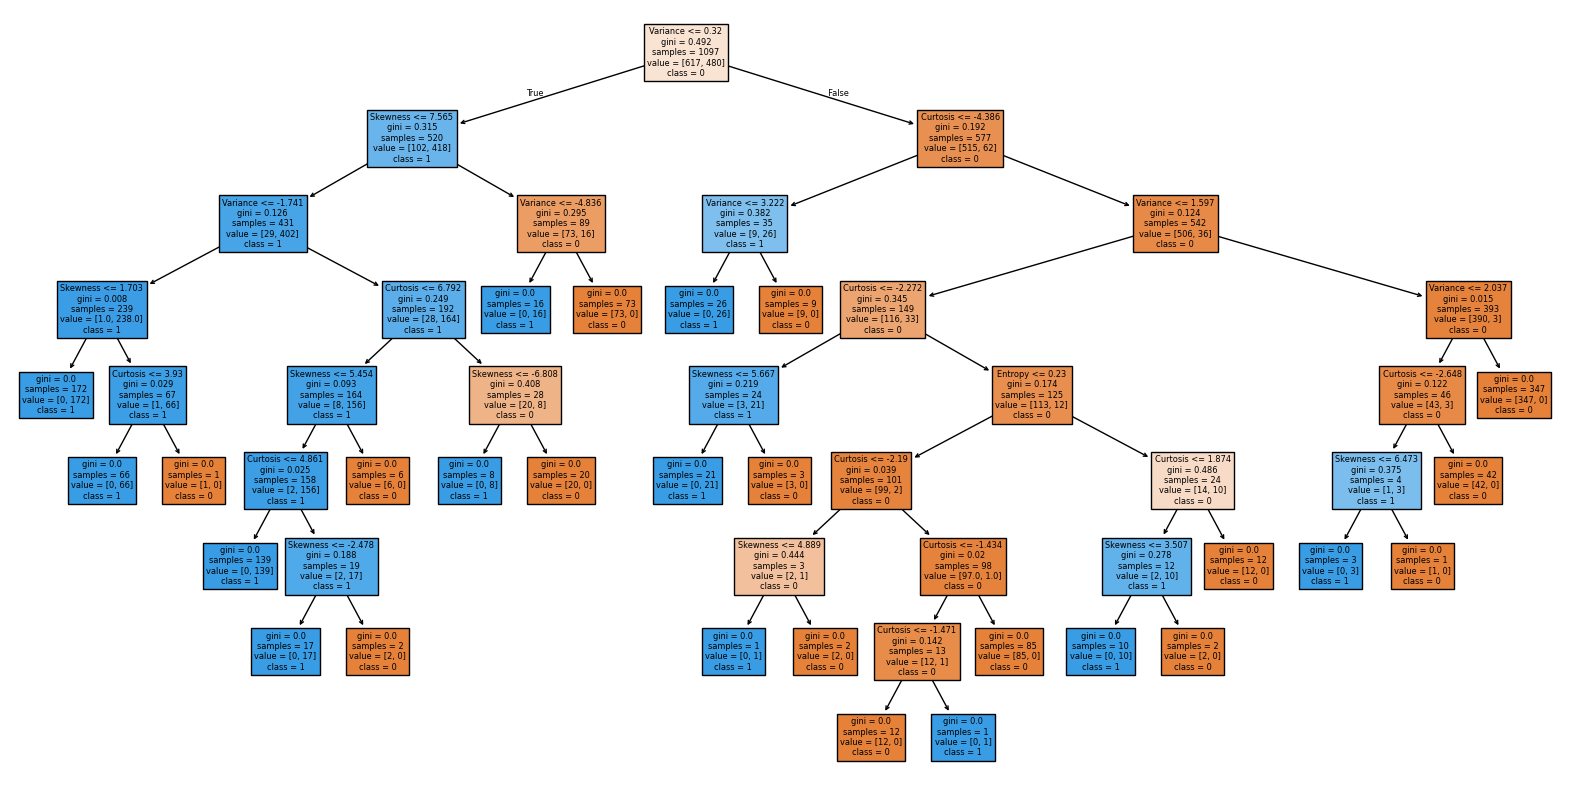

In [59]:
# Visualization of Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(dt_gini,feature_names=x.columns,class_names=['0','1'],filled=True)
plt.show()

In [60]:
# we can also check which feature was important for predicting the class
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": dt_gini.feature_importances_
})

print(feature_importance.sort_values(
    by="Importance",
    ascending=False
))

    Feature  Importance
0  Variance    0.591546
1  Skewness    0.224756
2  Curtosis    0.172385
3   Entropy    0.011313


In [61]:
# save the file as .pkl
import pickle
with open('decision_tree_gini.pkl','wb') as file:
  pickle.dump(dt_gini,file)